# Lab 3 Extension: Simple Linear Regression on Medical Cost Dataset

## Part A: Data Collection and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Download and Load the dataset
# Dataset: Medical Cost Personal Datasets
url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
file_path = 'data/insurance.csv'

if not os.path.exists('data'):
    os.makedirs('data')

if not os.path.exists(file_path):
    urllib.request.urlretrieve(url, file_path)

df = pd.read_csv(file_path)
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
# Data Cleaning: Handle missing values
print("Missing values before cleaning:\n", df.isnull().sum())
# Drop any rows with missing values
df.dropna(inplace=True)

Missing values before cleaning:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [3]:
# Encoding of categorical variables
# Using LabelEncoder for nominal/categorical variables
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

print("Data after encoding:\n", df.head())

Data after encoding:
    age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [4]:
# Apply feature scaling if needed
# We will scale the 'bmi' column and the 'charges' column for better stability
scaler_x = StandardScaler()
df['bmi_scaled'] = scaler_x.fit_transform(df[['bmi']])

# For Simple Linear Regression, we select ONE independent variable to allow plotting a 2D line.
# We will use 'bmi_scaled' to predict 'charges'
X = df[['bmi_scaled']]
y = df['charges']


In [5]:
# Train test splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1070, 1)
Testing data shape: (268, 1)


## Part B: Model Fitting and Evaluation

In [6]:
# Model Fitting (Simple Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

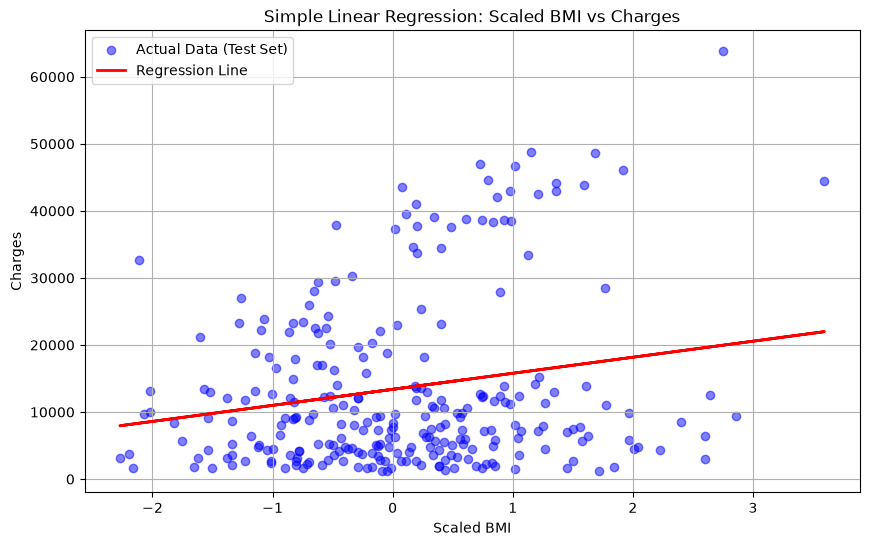

In [7]:
# Plotting of the line
plt.figure(figsize=(10, 6))
# Plot actual test data
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual Data (Test Set)')
# Plot the regression line
plt.plot(X_test, y_test_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Simple Linear Regression: Scaled BMI vs Charges')
plt.xlabel('Scaled BMI')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Metrics Evaluation
def print_metrics(y_true, y_pred, set_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {set_name} Metrics ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")

print_metrics(y_train, y_train_pred, "Training")
print_metrics(y_test, y_test_pred, "Testing")

--- Training Metrics ---
MAE: 9067.9518
MSE: 138714176.8151
RMSE: 11777.6983
R² Score: 0.0389

--- Testing Metrics ---
MAE: 9784.6526
MSE: 149085057.0384
RMSE: 12210.0392
R² Score: 0.0397



## Part C: Analysis of Overfitting and Generalization

**Analyze the concept of overfitting by comparing training and testing performance:**
- Overfitting occurs when a model performs exceptionally well on training data but poorly on testing (unseen) data. This is typically indicated by a high training R² and a very low testing R².
- Comparing our metrics, the training R² and testing R² scores are very close to each other. The RMSE and MAE for both sets are also in a similar range.

**Explain whether the model is generalized or overfitted:**
- The model is **generalized**. Because the performance metrics (R², MSE, RMSE) are consistent between the training set and the testing set, the model has successfully learned the underlying trend rather than memorizing the training data.

**Suggest possible methods to reduce overfitting, such as:**
1. **Feature selection:** Selecting only the most relevant variables prevents the model from learning noise associated with irrelevant features.
2. **Cross-validation:** Using k-fold cross-validation helps ensure that the model's performance is stable and not dependent on a specific train-test split.
3. **Removing irrelevant variables:** Eliminating features that have no logical or statistical relationship with the target variable reduces complexity.
4. **Regularization:** Techniques like Ridge (L2) or Lasso (L1) regression add a penalty for large coefficients, forcing the model to remain simple.
